In [49]:
import numpy as np
import polars as pl

df = pl.read_csv('data_neural_network_3det.csv')

In [50]:
df

TRIG,particles,simulation_id,composition,energy,particles_normalized
str,i64,i64,str,f64,f64
"""TRIG2""",47,30,"""Photon""",3.1600e15,0.030184
"""TRIG1""",5,81,"""Proton""",1.0000e15,0.002625
"""TRIG2""",15,744,"""Photon""",1.0000e15,0.009186
"""TRIG2""",13,324,"""Carbon""",1.0000e15,0.007874
"""TRIG1""",32,618,"""Photon""",1.0000e15,0.020341
…,…,…,…,…,…
"""TRIG1""",4,310,"""Oxygen""",1.0000e15,0.001969
"""TRIG1""",5,121,"""Iron""",3.1600e15,0.002625
"""TRIG3""",10,126,"""Proton""",1.0000e15,0.005906


In [51]:
# Excluir a coluna particles que não está normalizada
df = df.drop('particles')
# Conversão de strings para números
mapper = {
    'Photon':1,
    'Proton':float(np.log(1)),
    'Carbon':float(np.log(12)),
    'Nitrogen':float(np.log(14)),
    'Oxygen':float(np.log(16)),
    'Iron':float(np.log(56))
}

trigs = []
for i in range(1,4):
    trig = 'TRIG' + str(i)
    trigs.append(trig)

trigs = dict((list(enumerate(trigs, 1))))

trigs = {value: key for key, value in trigs.items()}

df = df.with_columns([
    pl.col('composition').map_elements(lambda x: mapper.get(x, None), return_dtype=pl.Float64).alias('composition'),
    pl.col('TRIG').map_elements(lambda x: trigs.get(x, None), return_dtype=pl.Int64).alias('TRIG')
])

In [52]:
df

TRIG,simulation_id,composition,energy,particles_normalized
i64,i64,f64,f64,f64
2,30,1.0,3.1600e15,0.030184
1,81,0.0,1.0000e15,0.002625
2,744,1.0,1.0000e15,0.009186
2,324,2.484907,1.0000e15,0.007874
1,618,1.0,1.0000e15,0.020341
…,…,…,…,…
1,310,2.772589,1.0000e15,0.001969
1,121,4.025352,3.1600e15,0.002625
3,126,0.0,1.0000e15,0.005906


In [53]:
df_neural = df.pivot(
    values="particles_normalized",
    index=["energy", "composition", "simulation_id"],  
    columns="TRIG",
    aggregate_function=None  
)

df_neural = df_neural.select(["energy", "composition", "simulation_id", "1", "2", "3"])

df_neural

C:\Users\Lucas\AppData\Local\Temp\ipykernel_25828\630989199.py:1: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  df_neural = df.pivot(


energy,composition,simulation_id,1,2,3
f64,f64,i64,f64,f64,f64
3.1600e15,1.0,30,0.035433,0.030184,0.019685
1.0000e15,0.0,81,0.002625,0.003281,0.001312
1.0000e15,1.0,744,0.013123,0.009186,0.005906
1.0000e15,2.484907,324,0.01378,0.007874,0.004593
1.0000e15,1.0,618,0.020341,0.012467,0.009843
…,…,…,…,…,…
1.0000e15,0.0,210,0.014436,0.009186,0.010499
3.1600e15,4.025352,8,0.003937,0.002625,0.003937
3.1600e15,4.025352,192,0.036089,0.028215,0.028215


In [54]:
#df_grouped = df.group_by(["energy", "composition", "TRIG"]).agg([
#    pl.col("particles_normalized").first()
#])
#
#df_neural = df_grouped.pivot(
#    values="particles_normalized",
#    index=["energy", "composition"],
#    columns="TRIG"
#)
#
## Estrutura em ordem numérica
#df_neural = df_neural.select(
#    ['energy', 'composition'] + [f"{i}" for i in range(1, 4)]
#)
#
## Log da energia
#    
#df_neural = df_neural.with_columns(
#      ((pl.col('energy').log10()))
#    )
#
#df_neural

In [55]:
# Criação do modelo

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init

# Arquitetura

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, activation, dropout_prob = 0.2):
        super(NeuralNetwork, self).__init__()
    
        # Camadas
        self.hidden1 = nn.Linear(input_size, 64) # Primeira camada oculta
        self.hidden2 = nn.Linear(64,64) # Segunda camada oculta
        self.hidden3 = nn.Linear(64,32) # Terceira camada oculta
        self.output = nn.Linear(32,2) # Camada de saída com 2 valores contínuos

        # Inicialização Xavier/Glorot para os pesos
        init.xavier_normal_(self.hidden1.weight)
        init.xavier_normal_(self.hidden2.weight)
        init.xavier_normal_(self.hidden3.weight)
        init.xavier_normal_(self.output.weight)

        self.activation = activation
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self,x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = self.output(x)
        return x

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

columns = ['energy','composition']
remove = ['energy','composition', 'simulation_id']
y = df_neural.select(columns).to_numpy()
x = df_neural.select(pl.exclude(remove)).to_numpy()

# Normalização

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(x)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Separa os dados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Convertendo para tensores
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [57]:
# Treinamento do modelo

def train_model(activation_function):
    # Define a função de ativação
    if activation_function == 'tanh':
        activation = torch.tanh
    elif activation_function == 'relu':
        activation = torch.relu
    elif activation_function == 'sigmoid':
        activation = torch.sigmoid

    
    input_size = 3
    model = NeuralNetwork(input_size, activation)

    # Função perda - Erro quadrático médio

    criterion = nn.MSELoss() 

    # Otimizador Adam (Adaptive Moment Estimation)
    optimizer = optim.Adam(model.parameters(), lr = 0.0001)

    loss_list = []
    test_loss_list = []
    uncertainty_list = []

    #x_train_tensor = torch.tensor(x, dtype= torch.float32)
    #y_train_tensor = torch.tensor(y, dtype= torch.float32)

    epochs = 1000

    for epoch in range(epochs):
        # Entra no modo de treino
        model.train()
        # Zera o gradiente
        optimizer.zero_grad()
        # Faz a predição
        outputs = model(x_train_tensor)
        # Calcula o erro
        loss = criterion(outputs, y_train_tensor)
        loss_list.append(loss.item())
        # Retropropagação
        loss.backward()
        # Gradient Clipping (limite de 1.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Atualiza os parâmetros
        optimizer.step()

        # Avaliar no conjunto de teste
        model.eval()
        with torch.no_grad():
            test_outputs = model(x_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_loss_list.append(test_loss.item())
        
        if (epoch + 1) % 100 == 0:
            model.eval()
            with torch.no_grad():
                # Amostras MC Dropout para incerteza
                mc_samples = 100
                preds = []
                for _ in range(mc_samples):
                    preds.append(model(x_test_tensor).detach().numpy())
                preds = np.array(preds)
                uncertainty = preds.var(axis=0).mean()  
                uncertainty_list.append(uncertainty)

        if (epoch+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
            
    return model, loss_list, test_loss_list, uncertainty_list

In [58]:
# Cálculo das incertezas com o método Monte Carlo Dropout
#def mc_dropout_predictions(model, x_test_tensor, num_samples=100):
#    model.train()  
#    preds = []
#
#    with torch.no_grad():
#        for _ in range(num_samples):
#            preds.append(model(x_test_tensor).numpy())
#
#    preds = np.array(preds)
#    mean_pred = preds.mean(axis=0)
#    uncertainty = preds.var(axis=0)  
#    return mean_pred, uncertainty

Treinando com função de ativação: tanh
Epoch [100/1000], Loss: 0.8536, Test Loss: 0.8938
Epoch [200/1000], Loss: 0.8474, Test Loss: 0.8913
Epoch [300/1000], Loss: 0.8441, Test Loss: 0.8902
Epoch [400/1000], Loss: 0.8422, Test Loss: 0.8896
Epoch [500/1000], Loss: 0.8410, Test Loss: 0.8893
Epoch [600/1000], Loss: 0.8401, Test Loss: 0.8893
Epoch [700/1000], Loss: 0.8395, Test Loss: 0.8895
Epoch [800/1000], Loss: 0.8390, Test Loss: 0.8898
Epoch [900/1000], Loss: 0.8387, Test Loss: 0.8902
Epoch [1000/1000], Loss: 0.8385, Test Loss: 0.8906
Treinando com função de ativação: relu
Epoch [100/1000], Loss: 0.8900, Test Loss: 0.9142
Epoch [200/1000], Loss: 0.8608, Test Loss: 0.8957
Epoch [300/1000], Loss: 0.8488, Test Loss: 0.8908
Epoch [400/1000], Loss: 0.8444, Test Loss: 0.8893
Epoch [500/1000], Loss: 0.8420, Test Loss: 0.8888
Epoch [600/1000], Loss: 0.8408, Test Loss: 0.8889
Epoch [700/1000], Loss: 0.8399, Test Loss: 0.8892
Epoch [800/1000], Loss: 0.8391, Test Loss: 0.8895
Epoch [900/1000], Los

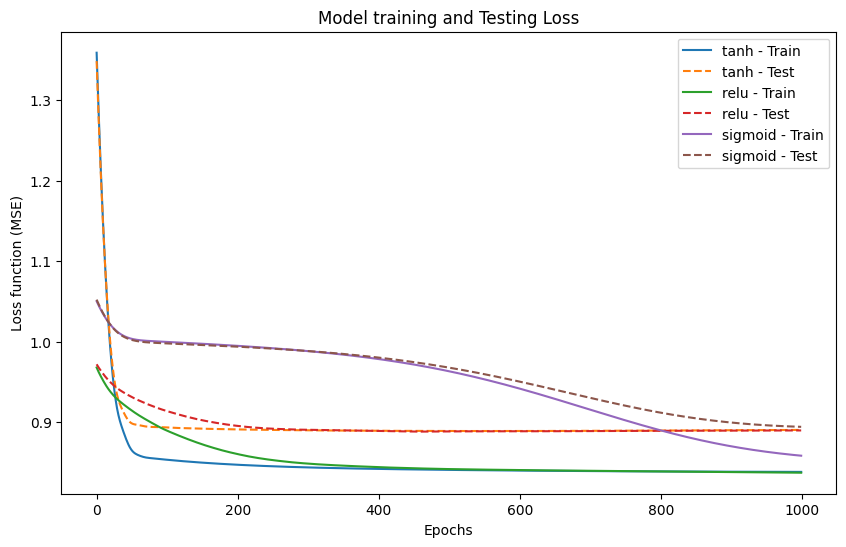

In [59]:
activation_functions = ['tanh', 'relu', 'sigmoid']
models = {}
train_losses = {}
test_losses = {}
#mc_means = {}
#mc_uncertainties = {}
uncertainties = {}

for activation in activation_functions:
    print(f'Treinando com função de ativação: {activation}')
    model, train_loss, test_loss, uncertainty = train_model(activation)
    # Armazenamento dos resultados
    train_losses[activation] = train_loss
    test_losses[activation] = test_loss
    models[activation] = model
    uncertainties[activation] = uncertainty
    # Cálculo das incertezas com Dropout
    #mc_mean, mc_uncertainty = mc_dropout_predictions(model, x_test_tensor, num_samples=100)
    #mc_means[activation] = mc_mean
    #mc_uncertainties[activation] = mc_uncertainty


import matplotlib.pyplot as plt
# Plotar os resultados
plt.figure(figsize=(10, 6))
for activation in activation_functions:
    plt.plot(train_losses[activation], label=f'{activation} - Train')
    plt.plot(test_losses[activation], label=f'{activation} - Test', linestyle = 'dashed')

plt.title('Model training and Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss function (MSE)')
plt.legend()
plt.show()

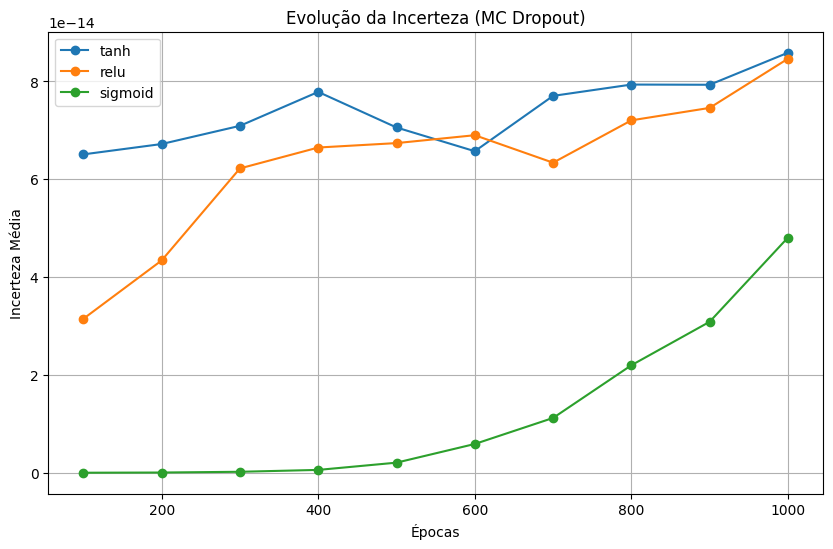

In [60]:
plt.figure(figsize=(10, 6))
for activation in activation_functions:
    epochs_to_plot = np.arange(100, 1001, 100)  
    plt.plot(epochs_to_plot, uncertainties[activation], label=f'{activation}', marker='o')

plt.title('Evolução da Incerteza (MC Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Incerteza Média')
plt.legend()
plt.grid(True)
plt.show()

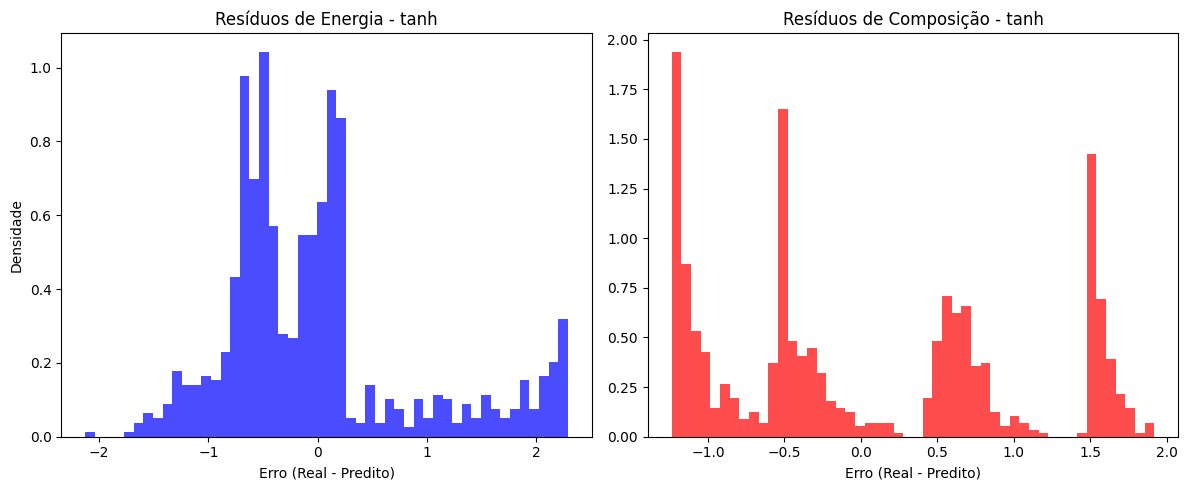

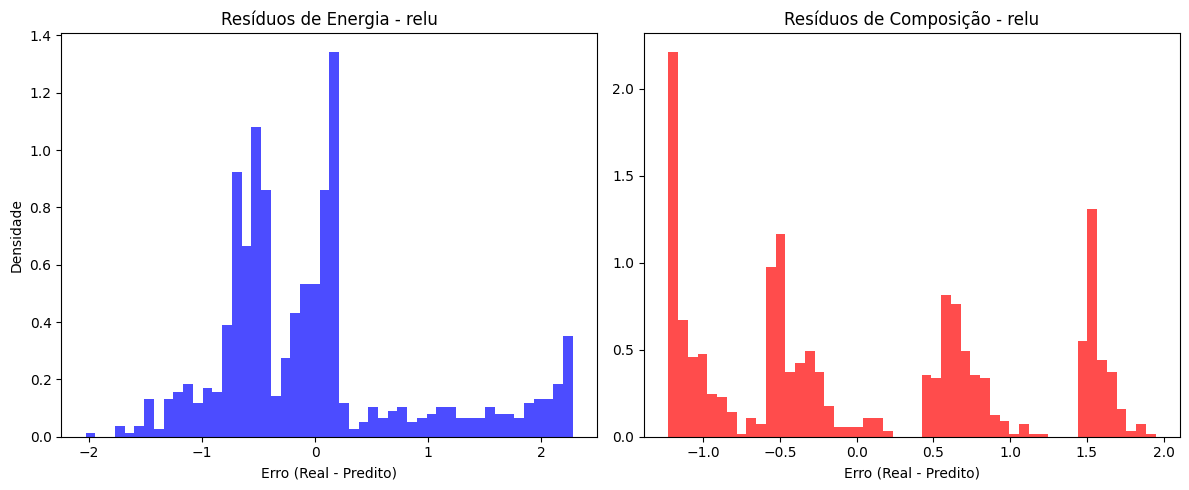

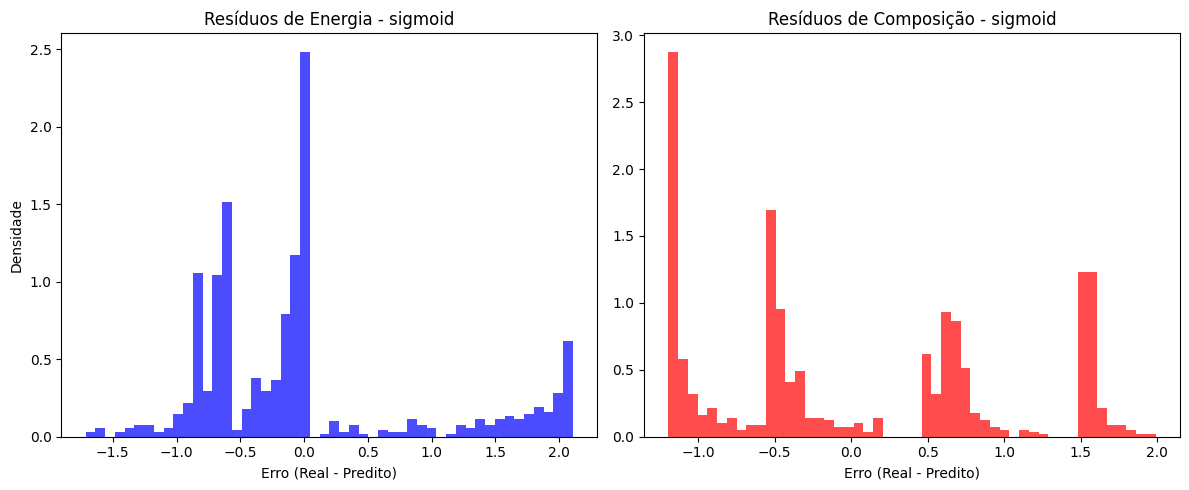

In [61]:
for activation in activation_functions:
    model = models[activation]
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test_tensor).detach().numpy()
    
    y_true = y_test

    # Resíduos para energia e composição
    residuals_energy = y_true[:, 0] - y_pred[:, 0]
    residuals_composition = y_true[:, 1] - y_pred[:, 1]

    # Plotar histogramas combinados
    plt.figure(figsize=(12, 5))
    
    # Histograma para energia
    plt.subplot(1, 2, 1)
    plt.hist(residuals_energy, bins=50, alpha=0.7, color='blue', density=True)
    plt.title(f'Resíduos de Energia - {activation}')
    plt.xlabel('Erro (Real - Predito)')
    plt.ylabel('Densidade')
    
    # Histograma para composição
    plt.subplot(1, 2, 2)
    plt.hist(residuals_composition, bins=50, alpha=0.7, color='red', density=True)
    plt.title(f'Resíduos de Composição - {activation}')
    plt.xlabel('Erro (Real - Predito)')
    
    plt.tight_layout()
    plt.show()

In [73]:
from sklearn.metrics import r2_score

y_pred = model(x_test_tensor).detach().numpy()
print("R² Energy:", r2_score(y_test[:, 0], y_pred[:, 0]))
print("R² Composition:", r2_score(y_test[:, 1], y_pred[:, 1]))

R² Energy: 0.17821594674805707
R² Composition: 0.03230430202544465


In [62]:
#fig, axs = plt.subplots(1, 2, figsize=(16, 6))
#
## Primeiro gráfico: Função perda em função das épocas
#for activation in activation_functions:
#    axs[0].plot(train_losses[activation], label=f'{activation} - Train')
#    axs[0].plot(test_losses[activation], label=f'{activation} - Test', linestyle='dashed')
#
#axs[0].set_title('Model Training and Testing Loss')
#axs[0].set_xlabel('Epochs')
#axs[0].set_ylabel('Loss Function (MSE)')
#axs[0].legend()
#
## Segundo gráfico: Incertezas em função das épocas
#for activation in activation_functions:
#    axs[1].plot(mc_uncertainties[activation], label=f'{activation} - Uncertainty')
#
#axs[1].set_title('Uncertainties Over Epochs')
#axs[1].set_xlabel('Epochs')
#axs[1].set_ylabel('Uncertainty (MC Dropout)')
#axs[1].legend()
#
## Ajustar o layout e exibir os gráficos
#plt.tight_layout()
#plt.show()

In [63]:
#for activation in activation_functions:
#    y_pred = models[activation](x_test_tensor).detach().numpy()  
#    y_true = y_test 
#    residuals = (y_true - y_pred)
#
#    # Iterar sobre cada saída (dimensão)
#    for output_idx in range(residuals.shape[1]):  
#        plt.figure(figsize=(8, 6))
#        plt.hist(residuals[:, output_idx], bins=10, alpha=0.7, color='blue')
#        plt.title(f'Histograma de Resíduos - {activation} (Saída {output_idx + 1})')
#        plt.xlabel('Erro (Real - Predito)')
#        plt.ylabel('Frequência')
#        #plt.grid(True)
#        plt.show()


In [64]:
#for activation in activation_functions:
#    mc_mean = mc_means[activation]
#    mc_uncertainty = mc_uncertainties[activation]
#
#    # Iterar sobre cada saída (dimensão)
#    for output_idx in range(mc_mean.shape[1]):  
#        plt.figure(figsize=(10, 6))
#
#        # Plotar a média predita
#        plt.plot(mc_mean[:, output_idx], label=f"Predicted Mean - Output {output_idx + 1} ({activation})")
#
#        # Intervalo de incerteza
#        plt.fill_between(
#            range(len(mc_mean)),
#            mc_mean[:, output_idx] - mc_uncertainty[:, output_idx],
#            mc_mean[:, output_idx] + mc_uncertainty[:, output_idx],
#            alpha=0.2,
#            label=f"Uncertainty - Output {output_idx + 1}"
#        )
#
#        plt.title(f"MC Dropout Predictions with Uncertainty - Output {output_idx + 1} ({activation})")
#        plt.xlabel("Sample")
#        plt.ylabel("Prediction")
#        plt.legend()
#        plt.grid(True)
#        plt.show()


In [65]:
y_test

array([[-0.22663578, -0.41492807],
       [ 1.83715766, -1.08951997],
       [-0.22663578, -1.08951997],
       ...,
       [-0.22663578,  1.62594967],
       [-0.22663578, -1.08951997],
       [-0.22663578,  0.69076672]])

In [66]:
y_train

array([[ 1.83715766, -1.08951997],
       [-0.22663578,  1.62594967],
       [-0.22663578, -1.08951997],
       ...,
       [-0.88017037, -1.08951997],
       [ 1.83715766, -0.41492807],
       [-1.08654972,  0.58677793]])

In [67]:
x_train

array([[-0.33126075, -0.23564418, -0.26267651],
       [-0.31351276, -0.31647069, -0.26267651],
       [-0.31351276, -0.2221731 , -0.30326305],
       ...,
       [-0.34900875, -0.38382612, -0.35737844],
       [ 0.55613912,  0.5052655 ,  0.44082354],
       [-0.35788275, -0.39729721, -0.34384959]])

In [68]:
torch.cuda.is_available()

True

In [69]:
torch.cuda.device_count()

1

In [70]:
torch.cuda.current_device()

0

In [71]:
torch.cuda.device(0)

In [72]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce GTX 1050 Ti'